# Task 3: Logistic Regression (Embedding-based Classifier)

## Objective
Predict sentiment polarity (positive/negative) from IMDB reviews using pretrained word embeddings and a linear classifier.

## Key Concepts
- Word Embedding (GloVe)
- Feature Aggregation (Mean Pooling)
- Linear Model
- Sigmoid Function
- Binary Cross Entropy (BCE)
- Decision Boundary in Embedding Space

## Model Formulation
\[
\hat{y} = \sigma(X\beta)
\]
where:
- \( \sigma \) is the sigmoid function
- \( X \) is the embedding feature matrix
- \( \beta \) is the parameter vector

In [138]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Step 1: Load Dataset

We use:
- IMDB Top 500 reviews dataset
- Pretrained GloVe embeddings

In [139]:
# Load IMDB dataset
df = pd.read_csv("./datasets/imdb_top_500.csv")

# Load GloVe embeddings
with open("./datasets/tiny_glove.json", "r") as f:
    glove = json.load(f)

print("Dataset size:", len(df))
print("Vocabulary size:", len(glove))

Dataset size: 500
Vocabulary size: 4993


## Step 2: Text Representation

Each review is converted into a fixed-length vector by averaging pretrained word embeddings.

In [140]:
import re
import numpy as np

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

def get_embedding(text, glove, dim=50):
    tokens = tokenize(text)
    vectors = [np.array(glove[t]) for t in tokens if t in glove]
    
    if not vectors:
        return np.zeros(dim)
    
    return np.mean(vectors, axis=0)

X = np.array([get_embedding(t, glove) for t in df["text"]])
y = df["label"].values.reshape(-1, 1) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b  = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [141]:
def bce_loss(y_true, y_pred):
    eps = 1e-8
    return -np.mean(
        y_true * np.log(y_pred + eps) +
        (1 - y_true) * np.log(1 - y_pred + eps)
    )

In [142]:

np.random.seed(42)
beta = np.random.randn(X_train_b.shape[1], 1) * 0.01

lr = 0.1 
epochs = 300
lambda_reg = 0.01 

for i in range(epochs):

    logits = X_train_b @ beta
    preds = sigmoid(logits)
    
    error = preds - y_train
  
    gradient = (X_train_b.T @ error) / len(y_train)
    

    reg_term = lambda_reg * beta
    reg_term[0] = 0
    

    beta -= lr * (gradient + reg_term)

    if i % 30 == 0:
        loss = bce_loss(y_train, preds)

        current_acc = np.mean((preds >= 0.5) == y_train)
        print(f"Epoch {i}, Loss: {loss:.4f}, Train Acc: {current_acc:.4f}")

Epoch 0, Loss: 0.6940, Train Acc: 0.4950
Epoch 30, Loss: 0.5489, Train Acc: 0.7275
Epoch 60, Loss: 0.5215, Train Acc: 0.7425
Epoch 90, Loss: 0.5073, Train Acc: 0.7425
Epoch 120, Loss: 0.4984, Train Acc: 0.7400
Epoch 150, Loss: 0.4923, Train Acc: 0.7425
Epoch 180, Loss: 0.4878, Train Acc: 0.7500
Epoch 210, Loss: 0.4845, Train Acc: 0.7475
Epoch 240, Loss: 0.4818, Train Acc: 0.7450
Epoch 270, Loss: 0.4798, Train Acc: 0.7425


In [143]:
train_pred = sigmoid(X_train_b @ beta)
test_pred = sigmoid(X_test_b @ beta)

train_class = (train_pred >= 0.5).astype(int)
test_class = (test_pred >= 0.5).astype(int)

In [144]:
train_acc = np.mean(train_class == y_train)
test_acc = np.mean(test_class == y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Positive ratio:", np.mean(y))

Train Accuracy: 0.7425
Test Accuracy: 0.69
Positive ratio: 0.5


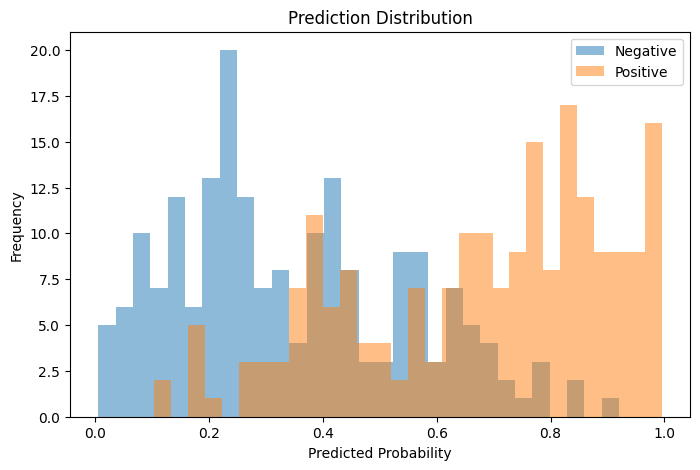

In [145]:
plt.figure(figsize=(8, 5))

plt.hist(train_pred[y_train.flatten()==0], bins=30, alpha=0.5, label="Negative")
plt.hist(train_pred[y_train.flatten()==1], bins=30, alpha=0.5, label="Positive")

plt.legend()
plt.title("Prediction Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()